In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv(r'/messy_ecommerce_operations.csv')

In [ ]:
df

,order_id,order_date,ship_date,delivery_date,customer_id,customer_name,customer_email,customer_segment,sales_channel,country,...,reorder_point,days_in_stock,supplier_id,supplier_lead_time_days,payment_method,payment_status,fulfillment_status,order_status,warehouse_id,notes
0,ORD-482615-15795,December 15 2024,12/17/2024,12/21/2024,ff3aa69b,Customer_ff3aa69b,customer_ff3aa69b@example.com,B2C,Shopify,United Kingdom,...,50,82,SUP-03,19.0,Credit Card,Paid,Fulfilled,Completed,WH-CENTRAL,NaN
1,ORD-377405-860,2023-12-19,21-12-2023,December 24 2023,36e8dd4e,Customer_36e8dd4e,customer_36e8dd4e@example.com,B2C,Shopify,USA,...,50,78,SUP-07,NaN,Credit Card,Paid,Fulfilled,Completed,WH-EAST,NaN
2,ORD-127168-54886,05/11/2024,14-05-2024,2024-05-18,c041f410,Customer_c041f410,customer_c041f410@example.com,B2C,Shopify,United States,...,50,48,SUP-09,15.0,Mastercard,PAID,Fulfilled,Completed,WH-WEST,NaN
3,ORD-446922-6265,2022-07-07,July 10 2022,2022-07-17,1e6ea9e7,Customer_1e6ea9e7,customer_1e6ea9e7@example.com,B2C,Shopify,Canada,...,50,17,SUP-10,14.0,PayPal,PAID,Fulfilled,Completed,WH-CENTRAL,NaN
4,ORD-638428-37194,06-12-2024,2024-12-09,2024-12-14,ce9d70ac,Customer_ce9d70ac,customer_ce9d70ac@example.com,B2C,Shopify,United States,...,50,67,SUP-05,8.0,PayPal,Paid,Fulfilled,Completed,WH-CENTRAL,Box was dented
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD-672075-63640,2023-09-12,13-09-2023,18-09-2023,b571b74b,Customer_b571b74b,customer_b571b74b@example.com,B2C,Shopify,United States,...,50,33,SUP-02,12.0,Visa,Paid,Fulfilled,Returned,WH-WEST,NaN
99996,ORD-736858-57364,28-10-2024,10/30/2024,11/06/2024,e5312687,Customer_e5312687,customer_e5312687@example.com,B2C,Shopify,United States,...,50,103,SUP-09,NaN,BNPL,paid,Fulfilled,Completed,WH-EAST,Box was dented
99997,ORD-915987-49922,2022-11-10,November 11 2022,2022-11-18,046bd25e,Customer_046bd25e,customer_046bd25e@example.com,B2C,Shopify,United States,...,50,57,SUP-06,10.0,BNPL,Paid,Fulfilled,Completed,WH-WEST,Customer called
99998,ORD-556813-43307,2023-06-07,2023-06-09,June 16 2023,09f2412f,Customer_09f2412f,customer_09f2412f@example.com,B2C,Shopify,United States,...,50,104,SUP-03,19.0,Mastercard,Paid,Fulfilled,Completed,WH-EAST,NaN


In [ ]:
date_cols = ['order_date', 'ship_date', 'delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='mixed', errors='coerce')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 40 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   order_id                 100000 non-null  object        
 1   order_date               100000 non-null  datetime64[ns]
 2   ship_date                100000 non-null  datetime64[ns]
 3   delivery_date            96017 non-null   datetime64[ns]
 4   customer_id              100000 non-null  object        
 5   customer_name            100000 non-null  object        
 6   customer_email           100000 non-null  object        
 7   customer_segment         100000 non-null  object        
 8   sales_channel            100000 non-null  object        
 9   country                  100000 non-null  object        
 10  region                   97996 non-null   object        
 11  product_id               100000 non-null  object        
 12  product_name     

In [ ]:
df.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
delivery_date,3957
customer_id,0
customer_name,0
customer_email,0
customer_segment,0
sales_channel,0
country,0


In [ ]:
df.shape

(100000, 40)

In [ ]:
df.duplicated().sum()

np.int64(947)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['sales_channel'].unique()

array(['Shopify', 'Amazon', 'Wholesale'], dtype=object)

In [ ]:
channel_map = {
    'shop': 'Shopify',
    'shopify': 'Shopify',
    'AMZ': 'Amazon',
    'amazon': 'Amazon',
    'wholesale': 'Wholesale',
    'WHOLESALE': 'Wholesale',
    'AMAZON': 'Amazon',
    'SHOPIFY': 'Shopify'
}

df['sales_channel'] = df['sales_channel'].replace(channel_map)

In [ ]:
df['country'].unique()

array(['United Kingdom', 'USA', 'United States', 'Canada', 'US'],
      dtype=object)

In [ ]:
country_map = {
    'USA': 'United States',
    'US': 'United States'
}

df['country'] = df['country'].replace(country_map)


df['country'].unique()

array(['United Kingdom', 'United States', 'Canada'], dtype=object)

In [ ]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

,0
refund_amount,89.393557
return_reason,89.242123
return_date,88.890796
notes,68.010055
supplier_lead_time_days,14.984907
subcategory,4.970067
delivery_date,3.994831
unit_cogs,2.952965
region,1.991863
customer_segment,0.000000


In [ ]:
df.head(5)

,order_id,order_date,ship_date,delivery_date,customer_id,customer_name,customer_email,customer_segment,sales_channel,country,...,reorder_point,days_in_stock,supplier_id,supplier_lead_time_days,payment_method,payment_status,fulfillment_status,order_status,warehouse_id,notes
0,ORD-482615-15795,2024-12-15,2024-12-17,2024-12-21,ff3aa69b,Customer_ff3aa69b,customer_ff3aa69b@example.com,B2C,Shopify,United Kingdom,...,50,82,SUP-03,19.0,Credit Card,Paid,Fulfilled,Completed,WH-CENTRAL,NaN
1,ORD-377405-860,2023-12-19,2023-12-21,2023-12-24,36e8dd4e,Customer_36e8dd4e,customer_36e8dd4e@example.com,B2C,Shopify,United States,...,50,78,SUP-07,NaN,Credit Card,Paid,Fulfilled,Completed,WH-EAST,NaN
2,ORD-127168-54886,2024-05-11,2024-05-14,2024-05-18,c041f410,Customer_c041f410,customer_c041f410@example.com,B2C,Shopify,United States,...,50,48,SUP-09,15.0,Mastercard,PAID,Fulfilled,Completed,WH-WEST,NaN
3,ORD-446922-6265,2022-07-07,2022-07-10,2022-07-17,1e6ea9e7,Customer_1e6ea9e7,customer_1e6ea9e7@example.com,B2C,Shopify,Canada,...,50,17,SUP-10,14.0,PayPal,PAID,Fulfilled,Completed,WH-CENTRAL,NaN
4,ORD-638428-37194,2024-06-12,2024-12-09,2024-12-14,ce9d70ac,Customer_ce9d70ac,customer_ce9d70ac@example.com,B2C,Shopify,United States,...,50,67,SUP-05,8.0,PayPal,Paid,Fulfilled,Completed,WH-CENTRAL,Box was dented


In [ ]:
df['fulfillment_status'].unique()

array(['Fulfilled', 'Unfulfilled'], dtype=object)

In [ ]:
df['return_flag'].unique()
return_map = {
    'No': 'No', 'N': 'No', 'no': 'No', '0': 'No', 'FALSE': 'No',
    'Yes': 'Yes', 'Y': 'Yes', 'yes': 'Yes', '1': 'Yes', 'TRUE': 'Yes'
}

df['return_flag'] = df['return_flag'].replace(return_map)
df['return_flag'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df.drop(columns=['return_date'], inplace=True)
df.drop(columns=['notes'], inplace=True)

In [ ]:
# 1. Fill missing return reasons with a clear label
df['return_reason'] = df['return_reason'].fillna('Not Returned')

# 2. Fill missing refund amounts with 0.0
df['refund_amount'] = df['refund_amount'].fillna(0.0)

# 3. Leave return_date as NaT or fill missing with 'N/A'
# (Keeping it as NaT allows datetime filtering on returned orders later)

In [ ]:
df['region'].unique()

array(['ENG', 'NY', 'IL', 'QC', 'CA', 'SCT', 'FL', 'ON', 'BC', 'TX', nan],
      dtype=object)

In [ ]:
payment_map = {
    'CC': 'Credit Card',
    'Mastercard': 'Credit Card',
    'Visa': 'Credit Card',
}

df['payment_method'] = df['payment_method'].replace(payment_map)


In [ ]:
df.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
delivery_date,3957
customer_id,0
customer_name,0
customer_email,0
customer_segment,0
sales_channel,0
country,0


In [ ]:
df['category'].unique()

array(['Kitchen', 'Outdoor', 'Bedroom', 'Office', 'kitchen', 'Storage',
       'Storage & Organization', 'storage', 'bedroom', 'outdoor',
       'office'], dtype=object)

In [ ]:

df['category'] = df['category'].str.title()

df['category'] = df['category'].replace({'Storage & Organization': 'Storage'})

df['category'].unique()

array(['Kitchen', 'Outdoor', 'Bedroom', 'Office', 'Storage'], dtype=object)

In [ ]:
df['subcategory'].unique()

array(['Cutlery', 'Lighting', 'Decor', 'Utensils', 'Desks', 'Bedding',
       'Shelves', 'Baskets', 'Accessories', 'Chairs', 'Boxes', 'Patio',
       nan, 'Gardening', 'Cookware'], dtype=object)

In [ ]:
df['subcategory'] = df['subcategory'].fillna('Other')

In [ ]:
df['unit_cogs'].unique()

array([ 48.51,  67.29,  13.58, ..., 252.79, 261.3 , 183.37])

In [ ]:
df.head(1)

,order_id,order_date,ship_date,delivery_date,customer_id,customer_name,customer_email,customer_segment,sales_channel,country,region,product_id,product_name,category,subcategory,quantity,unit_price,unit_cogs,discount_pct,gross_revenue,net_revenue,cogs_total,gross_profit,gross_margin_pct,shipping_cost,return_flag,return_reason,refund_amount,inventory_on_hand,reorder_point,days_in_stock,supplier_id,supplier_lead_time_days,payment_method,payment_status,fulfillment_status,order_status,warehouse_id
0,ORD-482615-15795,2024-12-15,2024-12-17,2024-12-21,ff3aa69b,Customer_ff3aa69b,customer_ff3aa69b@example.com,B2C,Shopify,United Kingdom,ENG,SKU-KIT-028,Kitchen Cutlery Model F5,Kitchen,Cutlery,1,91.94,48.51,0%,91.94,91.94,48.51,43.43,0.4724,18.14,No,Not Returned,0.0,104,50,82,SUP-03,19.0,Credit Card,Paid,Fulfilled,Completed,WH-CENTRAL


In [ ]:

pd.set_option('display.max_columns', None)


pd.set_option('display.max_colwidth', None)

In [ ]:
df['payment_status'].unique()

array(['Paid', 'PAID', 'paid', 'Chargeback', 'CHARGEBACK', 'chargeback'],
      dtype=object)

In [ ]:
df['payment_status'] = df['payment_status'].str.title()
df['payment_status'].unique()

array(['Paid', 'Chargeback'], dtype=object)

In [ ]:
df['fulfillment_status'].unique()

array(['Fulfilled', 'Unfulfilled'], dtype=object)

In [ ]:
df.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
delivery_date,3957
customer_id,0
customer_name,0
customer_email,0
customer_segment,0
sales_channel,0
country,0


In [ ]:
df['supplier_lead_time_days']

,supplier_lead_time_days
0,19.0
1,NaN
2,15.0
3,14.0
4,8.0
...,...
99995,12.0
99996,NaN
99997,10.0
99998,19.0


In [ ]:
df['supplier_lead_time_days'] = df['supplier_lead_time_days'].fillna(df['supplier_lead_time_days'].median())

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(90461, 38)

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [74]:
df

,order_id,order_date,ship_date,delivery_date,customer_id,customer_name,customer_email,customer_segment,sales_channel,country,region,product_id,product_name,category,subcategory,quantity,unit_price,unit_cogs,discount_pct,gross_revenue,net_revenue,cogs_total,gross_profit,gross_margin_pct,shipping_cost,return_flag,return_reason,refund_amount,inventory_on_hand,reorder_point,days_in_stock,supplier_id,supplier_lead_time_days,payment_method,payment_status,fulfillment_status,order_status,warehouse_id
0,ORD-482615-15795,2024-12-15,2024-12-17,2024-12-21,ff3aa69b,Customer_ff3aa69b,customer_ff3aa69b@example.com,B2C,Shopify,United Kingdom,ENG,SKU-KIT-028,Kitchen Cutlery Model F5,Kitchen,Cutlery,1,91.94,48.51,0%,91.94,91.94,48.51,43.43,0.4724,18.14,No,Not Returned,0.00,104,50,82,SUP-03,19.0,Credit Card,Paid,Fulfilled,Completed,WH-CENTRAL
1,ORD-377405-860,2023-12-19,2023-12-21,2023-12-24,36e8dd4e,Customer_36e8dd4e,customer_36e8dd4e@example.com,B2C,Shopify,United States,NY,SKU-OUT-081,Outdoor Lighting Model D3,Outdoor,Lighting,2,132.16,67.29,0.0,264.32,264.32,134.58,129.74,0.4908,20.90,No,Not Returned,0.00,205,50,78,SUP-07,14.0,Credit Card,Paid,Fulfilled,Completed,WH-EAST
2,ORD-127168-54886,2024-05-11,2024-05-14,2024-05-18,c041f410,Customer_c041f410,customer_c041f410@example.com,B2C,Shopify,United States,IL,SKU-OUT-082,outdoor lighting model e4,Outdoor,Lighting,1,30.44,13.58,0%,30.44,30.44,13.58,16.86,0.5539,19.66,No,Not Returned,0.00,381,50,48,SUP-09,15.0,Credit Card,Paid,Fulfilled,Completed,WH-WEST
3,ORD-446922-6265,2022-07-07,2022-07-10,2022-07-17,1e6ea9e7,Customer_1e6ea9e7,customer_1e6ea9e7@example.com,B2C,Shopify,Canada,QC,SKU-BED-043,Bedroom Decor Model D3,Bedroom,Decor,3,135.32,36.41,0.0,405.96,405.96,109.23,296.73,0.7309,36.77,No,Not Returned,0.00,271,50,17,SUP-10,14.0,PayPal,Paid,Fulfilled,Completed,WH-CENTRAL
4,ORD-638428-37194,2024-06-12,2024-12-09,2024-12-14,ce9d70ac,Customer_ce9d70ac,customer_ce9d70ac@example.com,B2C,Shopify,United States,NY,SKU-KIT-033,Kitchen Utensils Model E4,Kitchen,Utensils,3,283.73,145.53,0.0,851.19,851.19,436.59,414.60,0.4871,28.37,No,Not Returned,0.00,385,50,67,SUP-05,8.0,PayPal,Paid,Fulfilled,Completed,WH-CENTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD-672075-63640,2023-09-12,2023-09-13,2023-09-18,b571b74b,Customer_b571b74b,customer_b571b74b@example.com,B2C,Shopify,United States,FL,SKU-OUT-073,Outdoor Gardening Model A0,Outdoor,Gardening,3,17.05,7.88,0.1,34.10,30.69,15.76,14.93,0.4865,11.80,Yes,Wrong item,45.58,40,50,33,SUP-02,12.0,Credit Card,Paid,Fulfilled,Returned,WH-WEST
99996,ORD-736858-57364,2024-10-28,2024-10-30,2024-11-06,e5312687,Customer_e5312687,customer_e5312687@example.com,B2C,Shopify,United States,FL,SKU-OUT-082,Outdoor Lighting Model E4,Outdoor,Other,2,30.44,13.58,0.0,30.44,30.44,13.58,16.86,0.5539,17.55,No,Not Returned,0.00,342,50,103,SUP-09,14.0,BNPL,Paid,Fulfilled,Completed,WH-EAST
99997,ORD-915987-49922,2022-11-10,2022-11-11,2022-11-18,046bd25e,Customer_046bd25e,customer_046bd25e@example.com,B2C,Shopify,United States,TX,SKU-KIT-019,Kitchen Cookware Model C2,Kitchen,Cookware,2,215.80,56.92,0.0,215.80,215.80,56.92,158.88,0.7362,7.51,No,Not Returned,0.00,201,50,57,SUP-06,10.0,BNPL,Paid,Fulfilled,Completed,WH-WEST
99998,ORD-556813-43307,2023-06-07,2023-06-09,2023-06-16,09f2412f,Customer_09f2412f,customer_09f2412f@example.com,B2C,Shopify,United States,NY,SKU-STO-014,Storage Boxes Model D3,Storage,Boxes,2,187.06,92.06,0.0,187.06,187.06,92.06,95.00,0.5079,9.15,No,Not Returned,0.00,495,50,104,SUP-03,19.0,Credit Card,Paid,Fulfilled,Completed,WH-EAST


/tmp/ipykernel_2139/1062791570.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='category', y='net_revenue', ci=None, palette='viridis')
/tmp/ipykernel_2139/1062791570.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='category', y='net_revenue', ci=None, palette='viridis')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Kitchen'),
  Text(1, 0, 'Outdoor'),
  Text(2, 0, 'Bedroom'),
  Text(3, 0, 'Office'),
  Text(4, 0, 'Storage')])

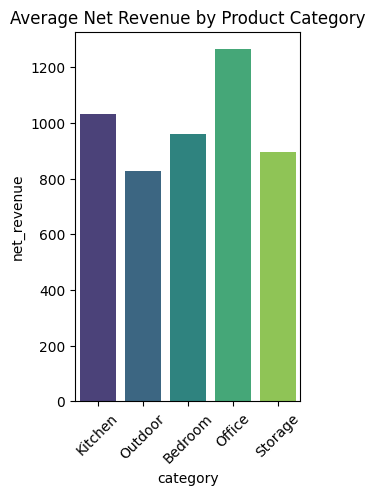

In [78]:
# 1. Net Revenue across Product Categories

plt.subplot(1, 2, 1)
sns.barplot(data=df, x='category', y='net_revenue', ci=None, palette='viridis')
plt.title('Average Net Revenue by Product Category')
plt.xticks(rotation=45)

/tmp/ipykernel_2139/1610067711.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sales_channel', y='gross_profit', palette='Set2')


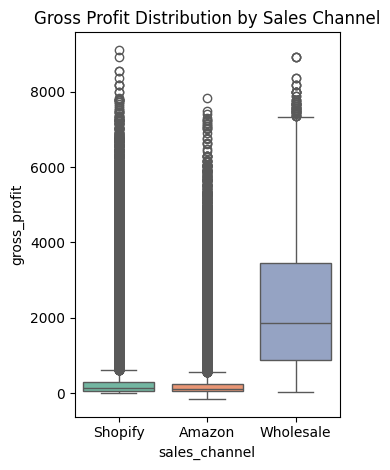

In [83]:
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='sales_channel', y='gross_profit', palette='Set2')
plt.title('Gross Profit Distribution by Sales Channel')

plt.tight_layout()
plt.show()

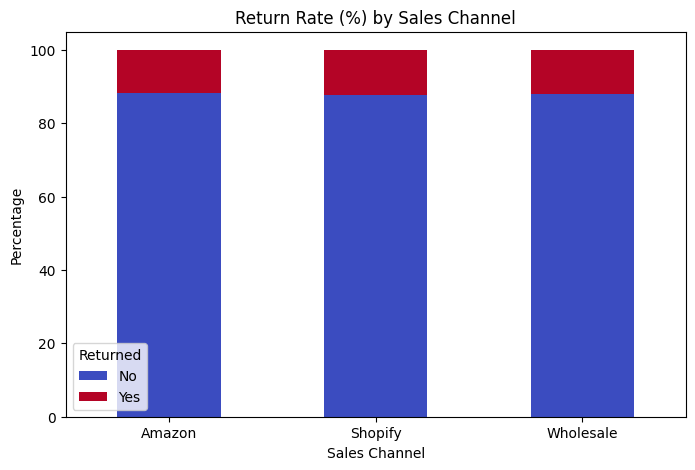

In [84]:
# Returns distribution by Sales Channel
ct = pd.crosstab(df['sales_channel'], df['return_flag'], normalize='index') * 100

ct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='coolwarm')
plt.title('Return Rate (%) by Sales Channel')
plt.ylabel('Percentage')
plt.xlabel('Sales Channel')
plt.legend(title='Returned')
plt.xticks(rotation=0)
plt.show()

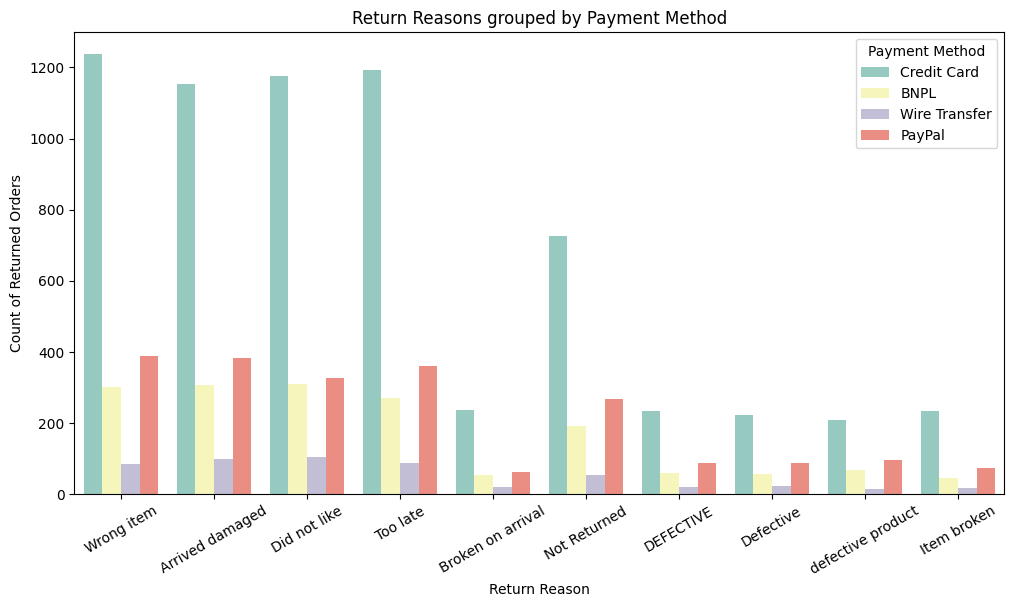

In [85]:
returned_df = df[df['return_flag'] == 'Yes']

plt.figure(figsize=(12, 6))
sns.countplot(
    data=returned_df,
    x='return_reason',
    hue='payment_method',
    palette='Set3'
)
plt.title('Return Reasons grouped by Payment Method')
plt.xlabel('Return Reason')
plt.ylabel('Count of Returned Orders')
plt.xticks(rotation=30)
plt.legend(title='Payment Method')
plt.show()

/tmp/ipykernel_2139/2910616601.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


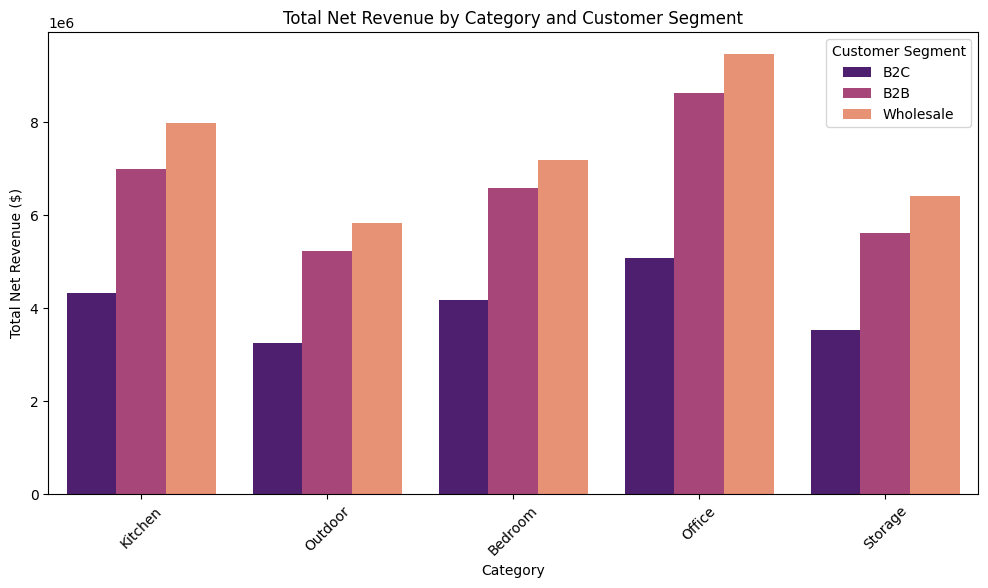

In [86]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x='category',
    y='net_revenue',
    hue='customer_segment',
    estimator=np.sum,
    ci=None,
    palette='magma'
)
plt.title('Total Net Revenue by Category and Customer Segment')
plt.ylabel('Total Net Revenue ($)')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.legend(title='Customer Segment')
plt.show()